In [ ]:
# Berlin Bike Counter Data – Exploratory Data Analysis

This notebook explores Berlin bike counter data from the Berlin Open Data portal.
The goal is to understand the raw dataset structure before building a reusable ETL pipeline.

In [ ]:
## 1. Load raw Excel file

In [2]:
import pandas as pd

df = pd.read_excel("data/raw/bike_counts.xlsx", sheet_name=0)
print(f"Shape: {df.shape}")
df.head()

Shape: (40, 2)


,Unnamed: 0,Unnamed: 1
0,NaN,Datenbereitsteller:
1,NaN,"Senatsverwaltung für Mobilität, Verkehr, Klima..."
2,NaN,NaN
3,NaN,NaN
4,NaN,Hinweise:


In [8]:
# Clean station column names by keeping only the station ID before the newline
cleaned_columns = {}

for col in df.columns:
    if col == "timestamp":
        cleaned_columns[col] = col
    else:
        cleaned_columns[col] = str(col).split("\n")[0].strip()

df = df.rename(columns=cleaned_columns)

df.head()

,timestamp,01-MI-AL-W,02-MI-JAN-N,02-MI-JAN-S,03-MI-SAN-O,03-MI-SAN-W,04-MI-NO,05-FK-OBB-O,05-FK-OBB-W,06-FK-FRA-O,...,18-TS-YOR-O,18-TS-YOR-W,19-TS-MON,20-TS-MAR-N,20-TS-MAR-S,21-NK-MAY,23-TK-KAI,24-MH-ALB,26-LI-PUP,27-RE-MAR
0,2025-01-01 00:00:00,5.0,10.0,5.0,20.0,13.0,4.0,19.0,16.0,10.0,...,3.0,5.0,8.0,2.0,2.0,15.0,7.0,3.0,6.0,3.0
1,2025-01-01 01:00:00,7.0,30.0,1.0,13.0,13.0,3.0,34.0,42.0,15.0,...,12.0,16.0,23.0,4.0,5.0,43.0,7.0,10.0,18.0,2.0
2,2025-01-01 02:00:00,14.0,23.0,0.0,16.0,12.0,0.0,41.0,41.0,12.0,...,23.0,10.0,31.0,4.0,10.0,49.0,5.0,12.0,9.0,12.0
3,2025-01-01 03:00:00,3.0,20.0,0.0,7.0,10.0,2.0,55.0,41.0,10.0,...,17.0,25.0,26.0,4.0,4.0,52.0,2.0,7.0,12.0,6.0
4,2025-01-01 04:00:00,3.0,15.0,1.0,1.0,10.0,3.0,39.0,32.0,4.0,...,9.0,10.0,9.0,2.0,1.0,28.0,3.0,6.0,4.0,1.0


In [5]:
df = pd.read_excel("data/raw/bike_counts.xlsx", sheet_name="Jahresdatei 2025", header=None)
print(df.head(10))

                                 0                       1   \
0  Zählstelle        Inbetriebnahme  01-MI-AL-W\n16.12.2021   
1               2025-01-01 00:00:00                       5   
2               2025-01-01 01:00:00                       7   
3               2025-01-01 02:00:00                      14   
4               2025-01-01 03:00:00                       3   
5               2025-01-01 04:00:00                       3   
6               2025-01-01 05:00:00                       9   
7               2025-01-01 06:00:00                      15   
8               2025-01-01 07:00:00                       3   
9               2025-01-01 08:00:00                       5   

                        2                        3                        4   \
0  02-MI-JAN-N\n01.04.2015  02-MI-JAN-S\n01.04.2015  03-MI-SAN-O\n01.06.2015   
1                       10                        5                       20   
2                       30                        1               

In [9]:
missing_summary = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_values"})
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_values"] / len(df) * 100
).round(2)

missing_summary = missing_summary.sort_values(
    "missing_values", ascending=False
)

missing_summary.head(10)

,column,missing_values,missing_percentage
28,19-TS-MON,2228,25.43
6,04-MI-NO,1977,22.57
10,06-FK-FRA-W,165,1.88
7,05-FK-OBB-O,25,0.29
18,14-CW-JU-O,1,0.01
22,16-SP-NO-O,1,0.01
23,16-SP-NO-W,1,0.01
24,17-SZ-BRE-O,1,0.01
25,17-SZ-BRE-W,1,0.01
26,18-TS-YOR-O,1,0.01


In [10]:
print(f"Number of hourly records: {len(df):,}")
print(f"Number of bike counter stations: {len(df.columns) - 1}")
print(f"Start date: {df['timestamp'].min()}")
print(f"End date: {df['timestamp'].max()}")
print(f"Total bike counts: {df.drop(columns='timestamp').sum().sum():,.0f}")

Number of hourly records: 8,760
Number of bike counter stations: 35
Start date: 2025-01-01 00:00:00
End date: 2025-12-31 23:00:00
Total bike counts: 28,332,132


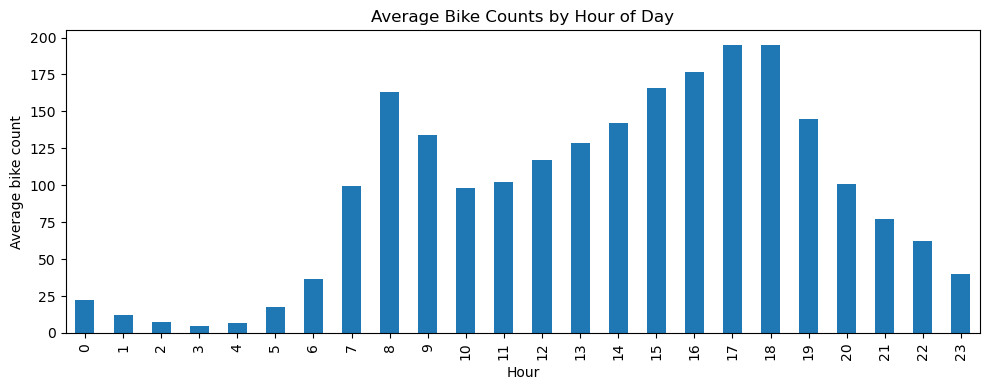

In [11]:
df_long = df.melt(
    id_vars="timestamp",
    var_name="station_id",
    value_name="bike_count"
)

df_long["hour"] = df_long["timestamp"].dt.hour
df_long["weekday"] = df_long["timestamp"].dt.day_name()
df_long["date"] = df_long["timestamp"].dt.date
df_long["month"] = df_long["timestamp"].dt.month

hourly_avg = df_long.groupby("hour")["bike_count"].mean()

plt.figure(figsize=(10, 4))
hourly_avg.plot(kind="bar")
plt.title("Average Bike Counts by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average bike count")
plt.tight_layout()
plt.show()

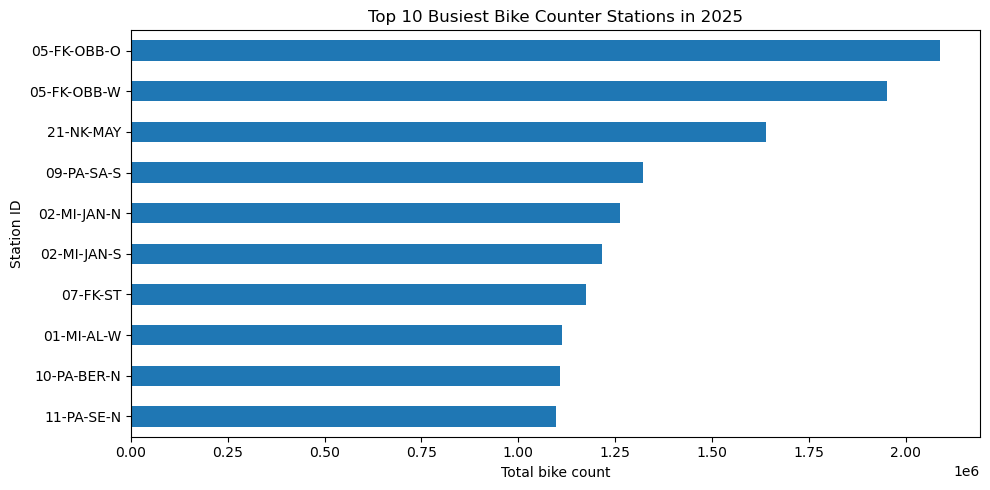

In [12]:
top_stations = (
    df_long.groupby("station_id")["bike_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_stations.sort_values().plot(kind="barh")
plt.title("Top 10 Busiest Bike Counter Stations in 2025")
plt.xlabel("Total bike count")
plt.ylabel("Station ID")
plt.tight_layout()
plt.show()